In [2]:
import pandas as pd
import joblib

In [13]:
train_y = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/y_train_beforeenc.csv")
train_X = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_train_beforeenc.csv")
test_X = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_test_beforeenc.csv")

from category_encoders import TargetEncoder
# 1. Extract multi-category columns for encoding
X_train_multi_cat = train_X[multi_cat_cols]
X_test_multi_cat = test_X[multi_cat_cols]

# 2. Fit target encoder on training data
target_encoder = TargetEncoder(smoothing=0.2)
target_encoder.fit(X_train_multi_cat, train_y)

# 3. Transform both train and test sets
X_train_multi_cat_encoded = target_encoder.transform(X_train_multi_cat)
X_test_multi_cat_encoded = target_encoder.transform(X_test_multi_cat)

# 4. Combine with the rest of the features
X_train_encoded = pd.concat([train_X.drop(columns=multi_cat_cols), X_train_multi_cat_encoded], axis=1)
X_test_encoded = pd.concat([test_X.drop(columns=multi_cat_cols), X_test_multi_cat_encoded], axis=1)

# Preview
X_train_encoded.head()


,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type,hardship_flag,disbursement_method,debt_settlement_flag,region
0,332529,26000.0,26000.0,26000.0,7.89,813.43,75000.0,30.62,0.0,725.0,...,0.237650,0.206484,0.206901,0.267951,0.035837,0.217465,0.219348,0.219328,0.200001,0.228057
1,1473102,7700.0,7700.0,7700.0,6.67,236.60,25000.0,8.16,0.0,685.0,...,0.233537,0.236456,0.228965,0.195607,0.120706,0.217465,0.219348,0.305323,0.200001,0.228057
2,1951339,7000.0,7000.0,7000.0,12.79,235.16,85000.0,34.36,0.0,760.0,...,0.220277,0.257933,0.228965,0.186082,0.144552,0.217465,0.219348,0.219328,0.200001,0.228057
3,371531,24000.0,24000.0,23975.0,10.99,785.62,160000.0,11.45,1.0,660.0,...,0.215014,0.195186,0.206901,0.281216,0.191280,0.217465,0.219348,0.219328,0.999852,0.204404
4,108041,5000.0,5000.0,5000.0,7.26,154.99,45000.0,7.20,0.0,695.0,...,0.221362,0.194889,0.228965,0.193300,0.191280,0.217465,0.219348,0.219328,0.200001,0.216390


In [22]:
xxx = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_train_final.csv")


In [18]:
from sklearn.preprocessing import StandardScaler

# Remove the target column from num_cols if it got in by mistake
if target_col in num_cols:
    num_cols.remove(target_col)

# Now scale only actual numeric features
scaler = StandardScaler()

standardized_train_X = X_train_encoded.copy()
standardized_train_X[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])

standardized_test_X = X_test_encoded.copy()
standardized_test_X[num_cols] = scaler.transform(X_test_encoded[num_cols])

standardized_train_X.head()

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type,hardship_flag,disbursement_method,debt_settlement_flag,region
0,-1.099773,1.348946,1.350520,1.352705,-1.131345,1.460829,0.057026,1.469929,-0.362496,0.913424,...,0.237650,0.206484,0.206901,0.267951,0.035837,0.217465,0.219348,0.219328,0.200001,0.228057
1,0.570069,-0.767006,-0.766371,-0.762712,-1.386205,-0.766928,-1.244733,-1.184051,-0.362496,-0.342371,...,0.233537,0.236456,0.228965,0.195607,0.120706,0.217465,0.219348,0.305323,0.200001,0.228057
2,1.270225,-0.847944,-0.847345,-0.843630,-0.107727,-0.772490,0.317377,1.911865,-0.362496,2.012245,...,0.220277,0.257933,0.228965,0.186082,0.144552,0.217465,0.219348,0.219328,0.200001,0.228057
3,-1.042672,1.117695,1.119166,1.118622,-0.483750,1.353425,2.270015,-0.795289,0.779638,-1.127243,...,0.215014,0.195186,0.206901,0.281216,0.191280,0.217465,0.219348,0.219328,0.999852,0.204404
4,-1.428431,-1.079196,-1.078700,-1.074823,-1.262953,-1.082112,-0.724030,-1.297489,-0.362496,-0.028422,...,0.221362,0.194889,0.228965,0.193300,0.191280,0.217465,0.219348,0.219328,0.200001,0.216390


In [3]:
xgb_model = joblib.load("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/xgb_credit_model.pkl")

In [4]:
test_df = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_test_beforeenc.csv")

In [27]:
test_df

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,emp_length_int,region,l_condition_Good Loan
0,1819301,10000.0,10000.0,10000.000000,36 months,13.68,340.23,C,C1,MORTGAGE,...,118872.0,97885.0,17000.0,83972.0,N,Cash,N,6.0,MidWest,True
1,1893562,8000.0,8000.0,8000.000000,36 months,7.62,249.30,A,A3,MORTGAGE,...,13700.0,4650.0,11000.0,0.0,N,Cash,N,2.0,West,True
2,1936067,22000.0,22000.0,21941.824197,60 months,16.77,544.04,D,D2,RENT,...,0.0,0.0,0.0,0.0,N,Cash,N,0.5,NorthEast,False
3,1323655,11000.0,11000.0,11000.000000,36 months,6.03,334.80,A,A1,MORTGAGE,...,233256.0,15918.0,30500.0,9256.0,N,Cash,N,2.0,MidWest,True
4,1805414,14000.0,14000.0,13975.000000,36 months,12.35,467.35,B,B4,OWN,...,21500.0,14263.0,15700.0,0.0,N,Cash,N,1.0,SouthEast,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272375,1159012,14000.0,14000.0,14000.000000,60 months,18.99,363.10,E,E1,OWN,...,120064.0,104282.0,10000.0,107764.0,N,Cash,N,7.0,NorthEast,True
272376,112795,6000.0,6000.0,6000.000000,36 months,9.17,191.28,B,B2,MORTGAGE,...,270544.0,74840.0,4500.0,96388.0,N,Cash,N,8.0,West,True
272377,301691,10000.0,10000.0,10000.000000,36 months,14.65,344.95,C,C5,RENT,...,13254.0,6851.0,5800.0,3954.0,N,Cash,N,10.0,SouthEast,True
272378,1298874,12000.0,12000.0,12000.000000,36 months,15.61,419.58,C,C5,MORTGAGE,...,63196.0,49376.0,11700.0,20296.0,N,Cash,N,6.0,SouthEast,True


In [5]:
X_test_stress = test_df.copy()

In [6]:
X_test_stress['annual_inc'] *= 0.8
X_test_stress['dti'] *= 1.3
# If interest rate is a feature:
X_test_stress['int_rate'] += 2.0

In [8]:
from category_encoders import TargetEncoder

In [9]:
cat_cols = X_test_stress.select_dtypes(include=['object']).columns.tolist()

In [10]:
multi_cat_cols =[col for col in cat_cols if X_test_stress[col].nunique()>2]

In [11]:
num_cols = [col for col in X_test_stress.select_dtypes(exclude=['object']).columns.tolist() if col not in ['id', 'loan_condition_int']]


In [15]:
target_col = "target"

In [16]:
from sklearn.preprocessing import StandardScaler

# Remove the target column from num_cols if it got in by mistake
if target_col in num_cols:
    num_cols.remove(target_col)

# Now scale only actual numeric features
scaler = StandardScaler()

In [19]:
# 1. Extract multi-category columns
X_stress_multi_cat = X_test_stress[multi_cat_cols]

# 2. Apply the same target encoder
X_stress_multi_cat_encoded = target_encoder.transform(X_stress_multi_cat)

# 3. Combine with the rest of the features
X_test_stress_encoded = pd.concat(
    [X_test_stress.drop(columns=multi_cat_cols), X_stress_multi_cat_encoded],
    axis=1
)

# 4. Standardize numeric columns
X_test_stress_encoded[num_cols] = scaler.transform(X_test_stress_encoded[num_cols])


In [23]:
# Align columns to match training features
X_test_stress_encoded = X_test_stress_encoded[xxx.columns]


In [24]:
y_pred_proba_stress = xgb_model.predict_proba(X_test_stress_encoded)[:, 1]

In [25]:
y_pred_proba_stress

array([0.1441971 , 0.00961374, 0.9315448 , ..., 0.91746175, 0.03793595,
       0.5078799 ], dtype=float32)

In [30]:
def simulate_pricing_strategies(
    y_pred_proba,
    loan_amounts,
    thresholds=np.arange(0.1, 0.91, 0.05),
    alpha_values=[0.5, 1.0, 1.5, 2.0, 3.0],
    LGD=0.45,
    r0=0.10,
    cost_per_loan=200
):
    """
    Simulate loan profits under different pricing strategies for varying PD thresholds and alpha (risk premium).

    Parameters:
    - y_pred_proba: array-like of predicted probabilities (PDs)
    - loan_amounts: array-like of loan principal amounts (EAD)
    - thresholds: array of PD cutoff thresholds to simulate
    - alpha_values: list of alpha values for pricing adjustment (r = r0 + alpha * PD)
    - LGD: Loss Given Default (e.g., 0.45)
    - r0: base interest rate (e.g., 0.10 for 10%)
    - cost_per_loan: fixed cost per loan (optional)

    Returns:
    - results_df: DataFrame with profitability metrics for each (alpha, threshold) combo
    """
    results = []

    for alpha in alpha_values:
        for threshold in thresholds:
            # Approve loans with PD <= threshold
            approved_mask = y_pred_proba <= threshold

            approved_PD = y_pred_proba[approved_mask]
            approved_EAD = loan_amounts[approved_mask]

            if len(approved_PD) == 0:
                continue  # skip if no loans are approved

            # Interest rate per loan: r_i = r0 + α * PD
            r_i = r0 + alpha * approved_PD

            # Profit per loan formula:
            # (1 - PD) * r * EAD - PD * LGD * EAD - cost_per_loan
            profit_per_loan = (
                (1 - approved_PD) * r_i * approved_EAD
                - approved_PD * LGD * approved_EAD
                - cost_per_loan
            )

            portfolio_profit = profit_per_loan.sum()
            avg_profit = profit_per_loan.mean()
            approval_rate = approved_mask.mean()

            results.append({
                'alpha': alpha,
                'threshold': threshold,
                'portfolio_profit': portfolio_profit,
                'approval_rate': approval_rate,
                'avg_profit_per_loan': avg_profit,
                'approved_loans': len(profit_per_loan)
            })

    results_df = pd.DataFrame(results)
    return results_df


In [32]:
import numpy as np

In [33]:
stress_results_df = simulate_pricing_strategies(
    y_pred_proba_stress,
    loan_amounts=test_df["funded_amnt"],
    thresholds=np.round(np.arange(0.1, 0.91, 0.05), 2),
    alpha_values=[0.5, 1.0, 1.5, 2.0, 3.0],
    LGD=0.45,
    r0=0.07694,
    cost_per_loan=500  # or whatever you used earlier
)


In [34]:
stress_results_df

,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans
0,0.5,0.10,7.375104e+07,0.444566,609.054705,121091
1,0.5,0.15,8.302408e+07,0.527135,578.238595,143581
2,0.5,0.20,8.673309e+07,0.576801,552.056812,157109
3,0.5,0.25,8.779138e+07,0.612824,525.945693,166921
4,0.5,0.30,8.707233e+07,0.638417,500.726472,173892
...,...,...,...,...,...,...
80,3.0,0.70,7.240204e+08,0.750371,3542.416704,204386
81,3.0,0.75,7.436364e+08,0.771356,3539.406472,210102
82,3.0,0.80,7.558347e+08,0.793641,3496.450710,216172
83,3.0,0.85,7.608023e+08,0.824323,3388.436783,224529


In [38]:
stress_results_df['sweetness_sharpe'] = stress_results_df['avg_profit_per_loan'] / (1 + (1 - stress_results_df['approval_rate']))
# Max profit
max_profit_row = stress_results_df.loc[stress_results_df['portfolio_profit'].idxmax()]

# Sweet spot (based on your function)
sweet_spot_row = stress_results_df.loc[stress_results_df['sweetness'].idxmax()]


In [42]:
stress_results_df

,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans,sweetness,sweetness_sharpe
0,0.5,0.10,7.375104e+07,0.444566,609.054705,121091,270.765266,391.565870
1,0.5,0.15,8.302408e+07,0.527135,578.238595,143581,304.809735,392.594399
2,0.5,0.20,8.673309e+07,0.576801,552.056812,157109,318.426807,387.898482
3,0.5,0.25,8.779138e+07,0.612824,525.945693,166921,322.312141,379.148494
4,0.5,0.30,8.707233e+07,0.638417,500.726472,173892,319.672251,367.753153
...,...,...,...,...,...,...,...,...
80,3.0,0.70,7.240204e+08,0.750371,3542.416704,204386,2658.126075,2834.774283
81,3.0,0.75,7.436364e+08,0.771356,3539.406472,210102,2730.143104,2880.742534
82,3.0,0.80,7.558347e+08,0.793641,3496.450710,216172,2774.927465,2898.350653
83,3.0,0.85,7.608023e+08,0.824323,3388.436783,224529,2793.165146,2882.114508


In [39]:
max_profit_row

alpha                  3.000000e+00
threshold              8.500000e-01
portfolio_profit       7.608023e+08
approval_rate          8.243226e-01
avg_profit_per_loan    3.388437e+03
approved_loans         2.245290e+05
sweetness              2.793165e+03
sweetness_sharpe       2.882115e+03
Name: 83, dtype: float64

In [40]:
sweet_spot_row

alpha                  3.000000e+00
threshold              8.500000e-01
portfolio_profit       7.608023e+08
approval_rate          8.243226e-01
avg_profit_per_loan    3.388437e+03
approved_loans         2.245290e+05
sweetness              2.793165e+03
sweetness_sharpe       2.882115e+03
Name: 83, dtype: float64

In [45]:
norm_results_df = pd.read_csv("normal_condition_simulation_pricing_strat.csv")
norm_results_df

,Unnamed: 0,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans,sweetness_sharpe,norm_profit,norm_approval,sweetness
0,0,0.5,0.10,9.762054e+09,0.444566,80617.502550,121091,51829.601280,0.929204,0.000000,0.557523
1,1,0.5,0.15,1.130612e+10,0.527135,78743.878920,143581,53463.061976,0.841088,0.189953,0.580634
2,2,0.5,0.20,1.216440e+10,0.576801,77426.484555,157109,54403.125139,0.779132,0.304211,0.589163
3,3,0.5,0.25,1.273878e+10,0.612824,76316.246113,166921,55015.546612,0.726917,0.387084,0.590984
4,4,0.5,0.30,1.311263e+10,0.638417,75406.741810,173892,55381.667694,0.684144,0.445962,0.588871
...,...,...,...,...,...,...,...,...,...,...,...
80,80,3.0,0.70,1.491417e+10,0.750371,72970.624194,204386,58393.821555,0.569574,0.703517,0.623151
81,81,3.0,0.75,1.505345e+10,0.771356,71648.299796,210102,58314.948092,0.507385,0.751795,0.605149
82,82,3.0,0.80,1.517143e+10,0.793641,70182.207161,216172,58176.895037,0.438435,0.803063,0.584286
83,83,3.0,0.85,1.529501e+10,0.824323,68120.411182,224529,57941.416033,0.341469,0.873647,0.554340


In [46]:
common_keys = set(
    zip(norm_results_df['alpha'], norm_results_df['threshold'])
).intersection(
    zip(stress_results_df['alpha'], stress_results_df['threshold'])
)

# Filter and align
baseline_filtered = norm_results_df.set_index(['alpha', 'threshold']).loc[list(common_keys)].sort_index()
stress_filtered = stress_results_df.set_index(['alpha', 'threshold']).loc[list(common_keys)].sort_index()

# Combine for delta analysis
comparison_df = baseline_filtered[['portfolio_profit', 'approval_rate', 'avg_profit_per_loan', 'sweetness']].copy()
comparison_df = comparison_df.rename(columns=lambda x: f"{x}_baseline")
for col in ['portfolio_profit', 'approval_rate', 'avg_profit_per_loan', 'sweetness']:
    comparison_df[f"{col}_stress"] = stress_filtered[f"{col}"]

# Add deltas
for col in ['portfolio_profit', 'approval_rate', 'avg_profit_per_loan', 'sweetness']:
    comparison_df[f"{col}_delta"] = comparison_df[f"{col}_stress"] - comparison_df[f"{col}_baseline"]

comparison_df.reset_index(inplace=True)

In [47]:
# Sort by the largest drop in profit
comparison_df.sort_values(by='portfolio_profit_delta').head(10)

# Or find the best preserved thresholds post-stress
comparison_df.sort_values(by='sweetness_delta', ascending=False).head(10)


,alpha,threshold,portfolio_profit_baseline,approval_rate_baseline,avg_profit_per_loan_baseline,sweetness_baseline,portfolio_profit_stress,approval_rate_stress,avg_profit_per_loan_stress,sweetness_stress,portfolio_profit_delta,approval_rate_delta,avg_profit_per_loan_delta,sweetness_delta
78,3.0,0.85,1.529501e+10,0.824323,68120.411182,0.554340,7.608023e+08,0.824323,3388.436783,2793.165146,-1.453421e+10,0.0,-64731.974399,2792.610806
77,3.0,0.80,1.517143e+10,0.793641,70182.207161,0.584286,7.558347e+08,0.793641,3496.450710,2774.927465,-1.441559e+10,0.0,-66685.756451,2774.343179
79,3.0,0.90,1.543384e+10,0.879246,64444.885841,0.501166,7.437498e+08,0.879246,3105.569659,2730.559410,-1.469009e+10,0.0,-61339.316182,2730.058244
76,3.0,0.75,1.505345e+10,0.771356,71648.299796,0.605149,7.436364e+08,0.771356,3539.406472,2730.143104,-1.430981e+10,0.0,-68108.893325,2729.537955
75,3.0,0.65,1.477916e+10,0.733795,73943.470020,0.635349,7.025857e+08,0.733795,3515.196039,2579.432218,-1.407657e+10,0.0,-70428.273981,2578.796869
74,3.0,0.60,1.466305e+10,0.721745,74587.359037,0.642430,6.834764e+08,0.721745,3476.676801,2509.275335,-1.397958e+10,0.0,-71110.682236,2508.632904
73,3.0,0.55,1.453965e+10,0.709916,75191.970435,0.648606,6.631469e+08,0.709916,3429.473108,2434.638837,-1.387650e+10,0.0,-71762.497328,2433.990231
72,3.0,0.50,1.438798e+10,0.696777,75810.825121,0.653977,6.387337e+08,0.696777,3365.511556,2345.009572,-1.374925e+10,0.0,-72445.313565,2344.355595
71,3.0,0.45,1.421202e+10,0.682888,76406.654664,0.658009,6.117016e+08,0.682888,3288.629734,2245.765378,-1.360032e+10,0.0,-73118.024929,2245.107369
70,3.0,0.40,1.399903e+10,0.667608,76984.174347,0.660245,5.811841e+08,0.667608,3196.076477,2133.725438,-1.341785e+10,0.0,-73788.097870,2133.065193


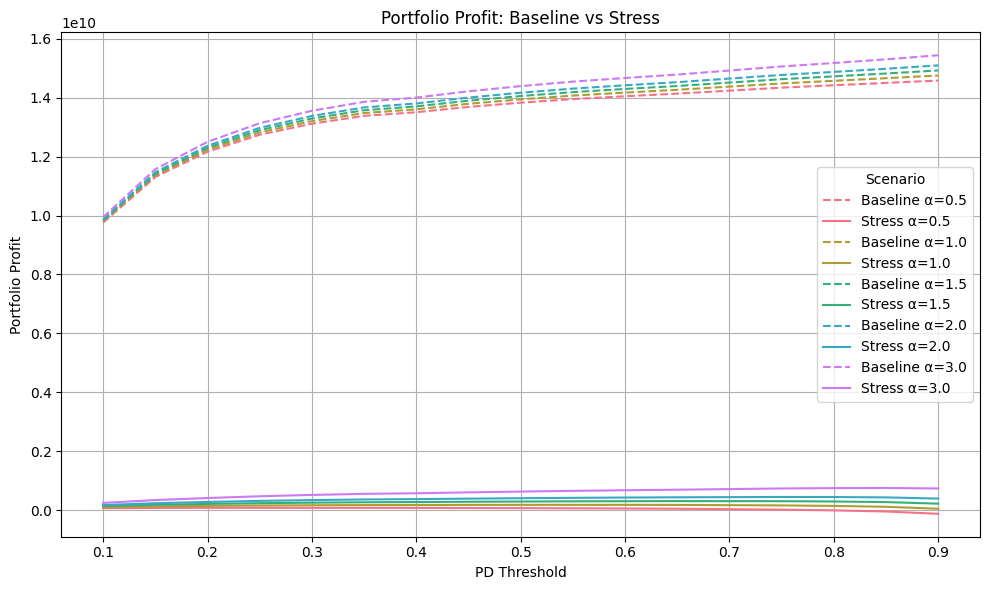

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

alphas = comparison_df['alpha'].unique()
palette = sns.color_palette("husl", len(alphas))

for i, alpha in enumerate(alphas):
    subset = comparison_df[comparison_df['alpha'] == alpha]
    plt.plot(subset['threshold'], subset['portfolio_profit_baseline'], label=f'Baseline α={alpha}', linestyle='--', color=palette[i])
    plt.plot(subset['threshold'], subset['portfolio_profit_stress'], label=f'Stress α={alpha}', linestyle='-', color=palette[i])

plt.title('Portfolio Profit: Baseline vs Stress')
plt.xlabel('PD Threshold')
plt.ylabel('Portfolio Profit')
plt.legend(title='Scenario')
plt.grid(True)
plt.tight_layout()
plt.show()


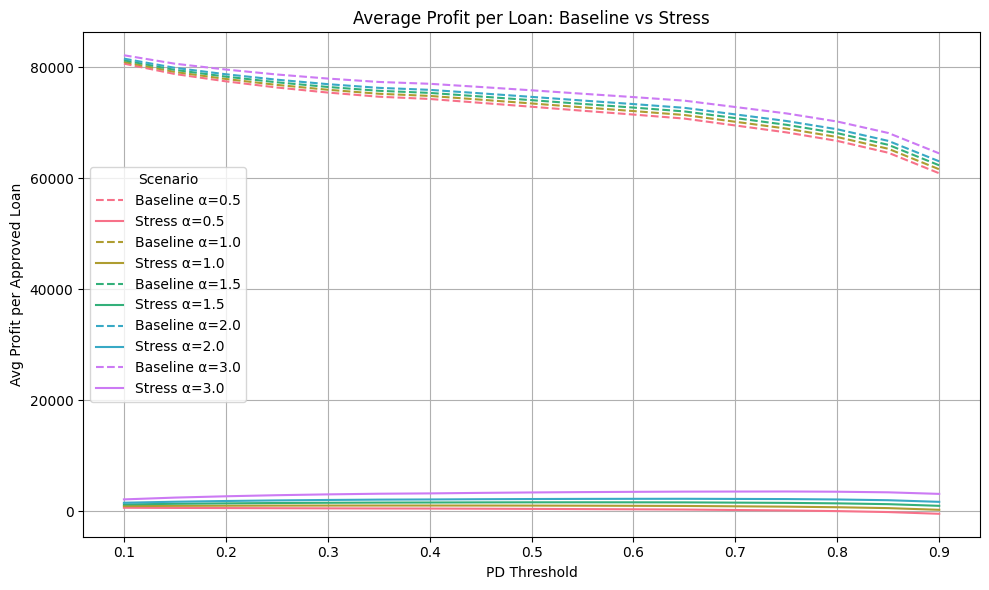

In [50]:
plt.figure(figsize=(10, 6))

for i, alpha in enumerate(alphas):
    subset = comparison_df[comparison_df['alpha'] == alpha]
    plt.plot(subset['threshold'], subset['avg_profit_per_loan_baseline'],
             label=f'Baseline α={alpha}', linestyle='--', color=palette[i])
    plt.plot(subset['threshold'], subset['avg_profit_per_loan_stress'],
             label=f'Stress α={alpha}', linestyle='-', color=palette[i])

plt.title('Average Profit per Loan: Baseline vs Stress')
plt.xlabel('PD Threshold')
plt.ylabel('Avg Profit per Approved Loan')
plt.legend(title='Scenario')
plt.grid(True)
plt.tight_layout()
plt.show()
